In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Payal\Downloads\archive (5)\PS_20174392719_1491204439457_log.csv")

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [5]:
#Column	Meaning
#step-Time step (1 step ≈ 1 hour in PaySim)
#type-Transaction type
#amount-Transaction amount
#nameOrig-Sender customer ID
#oldbalanceOrg-Sender balance BEFORE transaction
#newbalanceOrig-Sender balance AFTER transaction
#nameDest-Receiver customer ID
#oldbalanceDest-Receiver balance BEFORE
#newbalanceDest-Receiver balance AFTER
#isFraud-Fraud label (1 = fraud)
#isFlaggedFraud-System-flagged fraud

In [6]:
#Performing Exploratory Data Analysis (EDA)

In [7]:
#which transaction types exist
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [8]:
#How much fraud exists? #0 is normal transaction #1 is fraud transaction
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [9]:
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [10]:
df["isFraud"].value_counts(normalize=True) * 100   #fraud per

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [11]:
#Average transaction amount by type like which transactionsis risky?or have larger money? 
df.groupby("type")["amount"].mean()

type
CASH_IN     168920.242004
CASH_OUT    176273.964346
DEBIT         5483.665314
PAYMENT      13057.604660
TRANSFER    910647.009645
Name: amount, dtype: float64

In [12]:
# Fraud happens in specific transaction type so which
pd.crosstab(df["type"], df["isFraud"])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [13]:
#Transaction amounts distribution
df["amount"].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

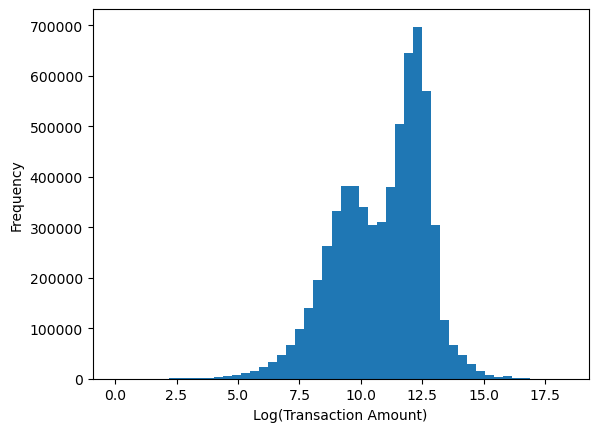

In [14]:
import numpy as np
import matplotlib.pyplot as plt
plt.hist(np.log1p(df["amount"]), bins=50)
plt.xlabel("Log(Transaction Amount)")
plt.ylabel("Frequency")
plt.show()

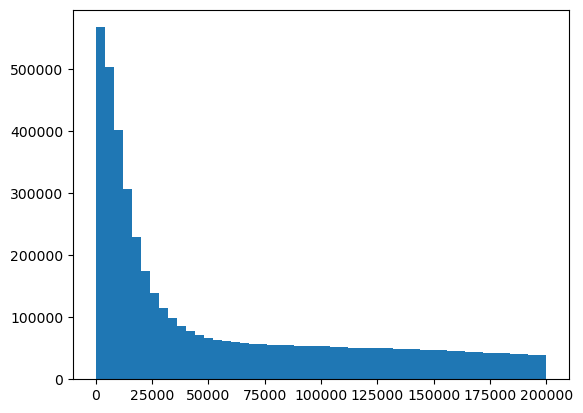

In [15]:
filtered = df[df["amount"] < 200000]

plt.hist(filtered["amount"], bins=50)
plt.show()

In [16]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [17]:
pd.crosstab(df["type"], df["isFraud"])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [18]:
#1st dia The filtered transaction amount distribution (transactions below 200,000) showed a heavily right-skewed pattern, indicating that the majority of users perform low-value transactions while high-value transactions become progressively less frequent. This reflects real-world financial behavior where routine payments and transfers are common, whereas large monetary movements are relatively rare. The observed long-tail distribution suggests the presence of behavioral outliers that may be relevant for fraud detection and customer spending pattern analysis.
#2nd dia The exploratory distribution analysis demonstrated that transaction amounts exhibit a non-normal, heavy-tailed distribution characteristic of real-world financial systems. Logarithmic transformation improved interpretability by reducing scale distortion caused by extreme values. The findings suggest that transactional behavior is dominated by frequent low-value operations, while a small proportion of high-value transactions contribute disproportionately to distribution spread. Such behavioral asymmetry is important for anomaly detection, fraud intelligence, and financial risk modeling.

In [19]:
print(df.columns)

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')


In [25]:
import seaborn as sns

In [26]:
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

In [32]:
# Loading ONLY a sample rows (100,000 rows)
df = pd.read_csv(r"C:\Users\Payal\Downloads\archive (5)\PS_20174392719_1491204439457_log.csv", 
                 nrows=100000) 

print(f"Loaded {len(df):,} rows (sample)")
print(f"Fraud rate: {df['isFraud'].mean():.4%}")

# only SIMPLE features not rolling
df['hour'] = df['step'] % 24
df['is_TRANSFER'] = (df['type'] == 'TRANSFER').astype(int)
df['is_CASH_OUT'] = (df['type'] == 'CASH_OUT').astype(int)

# Simple aggregations (fast on 100k rows)
df['balance_error'] = abs(df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount'])

print(" Feature engineering done in seconds!")
df.head()

Loaded 100,000 rows (sample)
Fraud rate: 0.1160%
 Feature engineering done in seconds!


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour,is_TRANSFER,is_CASH_OUT,balance_error
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,1,0,0,1.455192e-11
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1,0,0,1.136868e-12
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,1,1,0,0.000000e+00
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,1,0,1,0.000000e+00
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,1,0,0,0.000000e+00


In [33]:
#Customer-Level Behavioral Features (Still Fast)
# CUSTOMER BEHAVIORAL AGGREGATIONS


# Group byed the customer to understand behavior patterns
customer_features = df.groupby('nameOrig').agg({
    'amount': ['count', 'mean', 'std', 'sum'],
    'isFraud': 'max',  # Did this customer ever commit fraud?
    'hour': 'mean',  # Average transaction hour
    'is_TRANSFER': 'mean',  # % of transfers
    'is_CASH_OUT': 'mean',  # % of cash outs
    'balance_error': 'mean',  # Avg balance inconsistency
    'step': ['min', 'max']  # First and last transaction step
}).reset_index()

# Flatten the column names
customer_features.columns = ['customer_id', 'tx_count', 'avg_amount', 'std_amount', 
                            'total_amount', 'is_fraud_customer', 'avg_hour', 
                            'transfer_ratio', 'cashout_ratio', 'avg_balance_error',
                            'first_tx_step', 'last_tx_step']

# Calculated customer tenure (number of steps/hours active)
customer_features['tenure'] = customer_features['last_tx_step'] - customer_features['first_tx_step']

# Transaction frequency (transactions per hour)
customer_features['tx_frequency'] = customer_features['tx_count'] / (customer_features['tenure'] + 1)

# Risk score components
customer_features['high_value_ratio'] = customer_features['avg_amount'] / (customer_features['total_amount'] + 1)
customer_features['suspicious_behavior_score'] = (
    customer_features['transfer_ratio'] * 0.4 +
    customer_features['cashout_ratio'] * 0.3 +
    customer_features['avg_balance_error'] * 0.3
)

print(f"Created behavioral profiles for {len(customer_features):,} customers")
print("\nSample customer features:")
print(customer_features.head(10))
print("\nCustomer feature columns:")
print(customer_features.columns.tolist())

Created behavioral profiles for 100,000 customers

Sample customer features:
   customer_id  tx_count  avg_amount  std_amount  total_amount  \
0  C1000037689         1   451174.06         NaN     451174.06   
1  C1000039823         1     7781.12         NaN       7781.12   
2  C1000079132         1     2955.97         NaN       2955.97   
3  C1000109302         1    36834.52         NaN      36834.52   
4  C1000119377         1      144.56         NaN        144.56   
5  C1000148923         1   124952.20         NaN     124952.20   
6    C10001825         1     2655.04         NaN       2655.04   
7  C1000183504         1   158429.53         NaN     158429.53   
8  C1000187362         1   144720.75         NaN     144720.75   
9   C100022590         1   162472.67         NaN     162472.67   

   is_fraud_customer  avg_hour  transfer_ratio  cashout_ratio  \
0                  0      10.0             0.0            0.0   
1                  0       8.0             0.0            0.0   
2

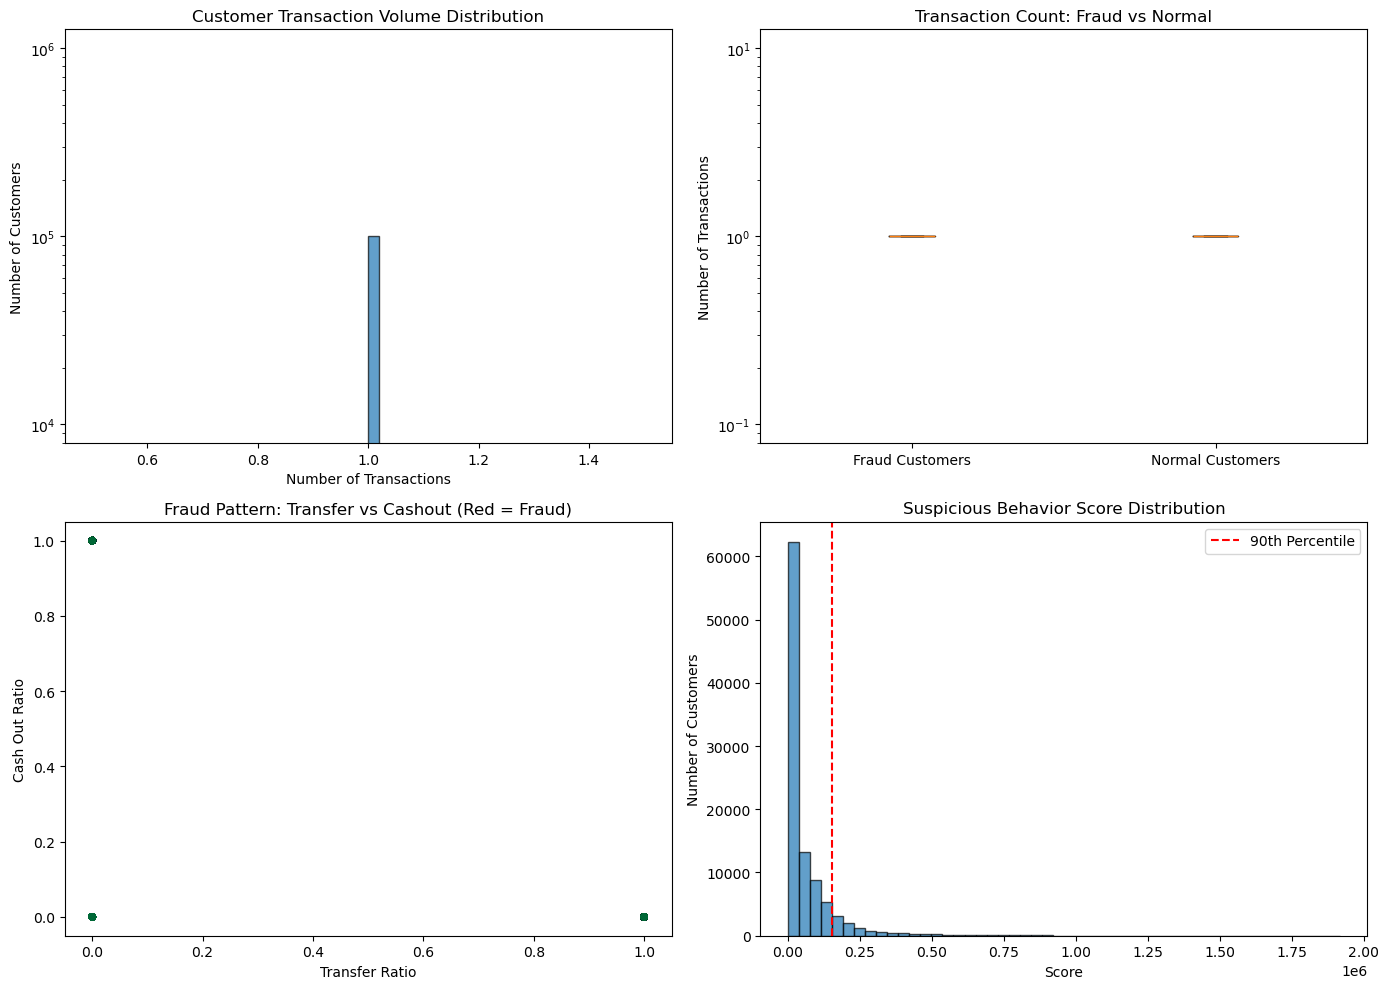


=== Customer Segmentation Summary ===
Total customers: 100,000
Fraudster customers: 116 (0.12%)

Top 5 customers by suspicious score:
       customer_id  suspicious_behavior_score  tx_count  transfer_ratio  \
94315   C890128330                1916415.781         1             1.0   
52623  C2022065686                1821446.881         1             1.0   
63360   C293394374                1703299.087         1             1.0   
77883   C574755786                1524861.820         1             1.0   
76656   C551242513                1509629.443         1             1.0   

       cashout_ratio  
94315            0.0  
52623            0.0  
63360            0.0  
77883            0.0  
76656            0.0  


In [34]:
#Visualizing Customer Segments
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of transaction counts
axes[0,0].hist(customer_features['tx_count'], bins=50, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Customer Transaction Volume Distribution')
axes[0,0].set_xlabel('Number of Transactions')
axes[0,0].set_ylabel('Number of Customers')
axes[0,0].set_yscale('log')

# Fraud customers vs normal (transaction patterns)
fraud_cust = customer_features[customer_features['is_fraud_customer'] == 1]
normal_cust = customer_features[customer_features['is_fraud_customer'] == 0]

axes[0,1].boxplot([fraud_cust['tx_count'], normal_cust['tx_count']], 
                  labels=['Fraud Customers', 'Normal Customers'])
axes[0,1].set_title('Transaction Count: Fraud vs Normal')
axes[0,1].set_ylabel('Number of Transactions')
axes[0,1].set_yscale('log')

# Transfer vs Cashout ratio (fraud pattern)
axes[1,0].scatter(customer_features['transfer_ratio'], 
                  customer_features['cashout_ratio'],
                  c=customer_features['is_fraud_customer'], 
                  cmap='RdYlGn_r', alpha=0.6, s=20)
axes[1,0].set_xlabel('Transfer Ratio')
axes[1,0].set_ylabel('Cash Out Ratio')
axes[1,0].set_title('Fraud Pattern: Transfer vs Cashout (Red = Fraud)')

#Suspicious behavior score distribution
axes[1,1].hist(customer_features['suspicious_behavior_score'], bins=50, alpha=0.7, edgecolor='black')
axes[1,1].axvline(customer_features['suspicious_behavior_score'].quantile(0.9), 
                  color='red', linestyle='--', label='90th Percentile')
axes[1,1].set_title('Suspicious Behavior Score Distribution')
axes[1,1].set_xlabel('Score')
axes[1,1].set_ylabel('Number of Customers')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== Customer Segmentation Summary ===")
print(f"Total customers: {len(customer_features):,}")
print(f"Fraudster customers: {customer_features['is_fraud_customer'].sum():,} ({customer_features['is_fraud_customer'].mean():.2%})")
print(f"\nTop 5 customers by suspicious score:")
print(customer_features.nlargest(5, 'suspicious_behavior_score')[['customer_id', 'suspicious_behavior_score', 'tx_count', 'transfer_ratio', 'cashout_ratio']])

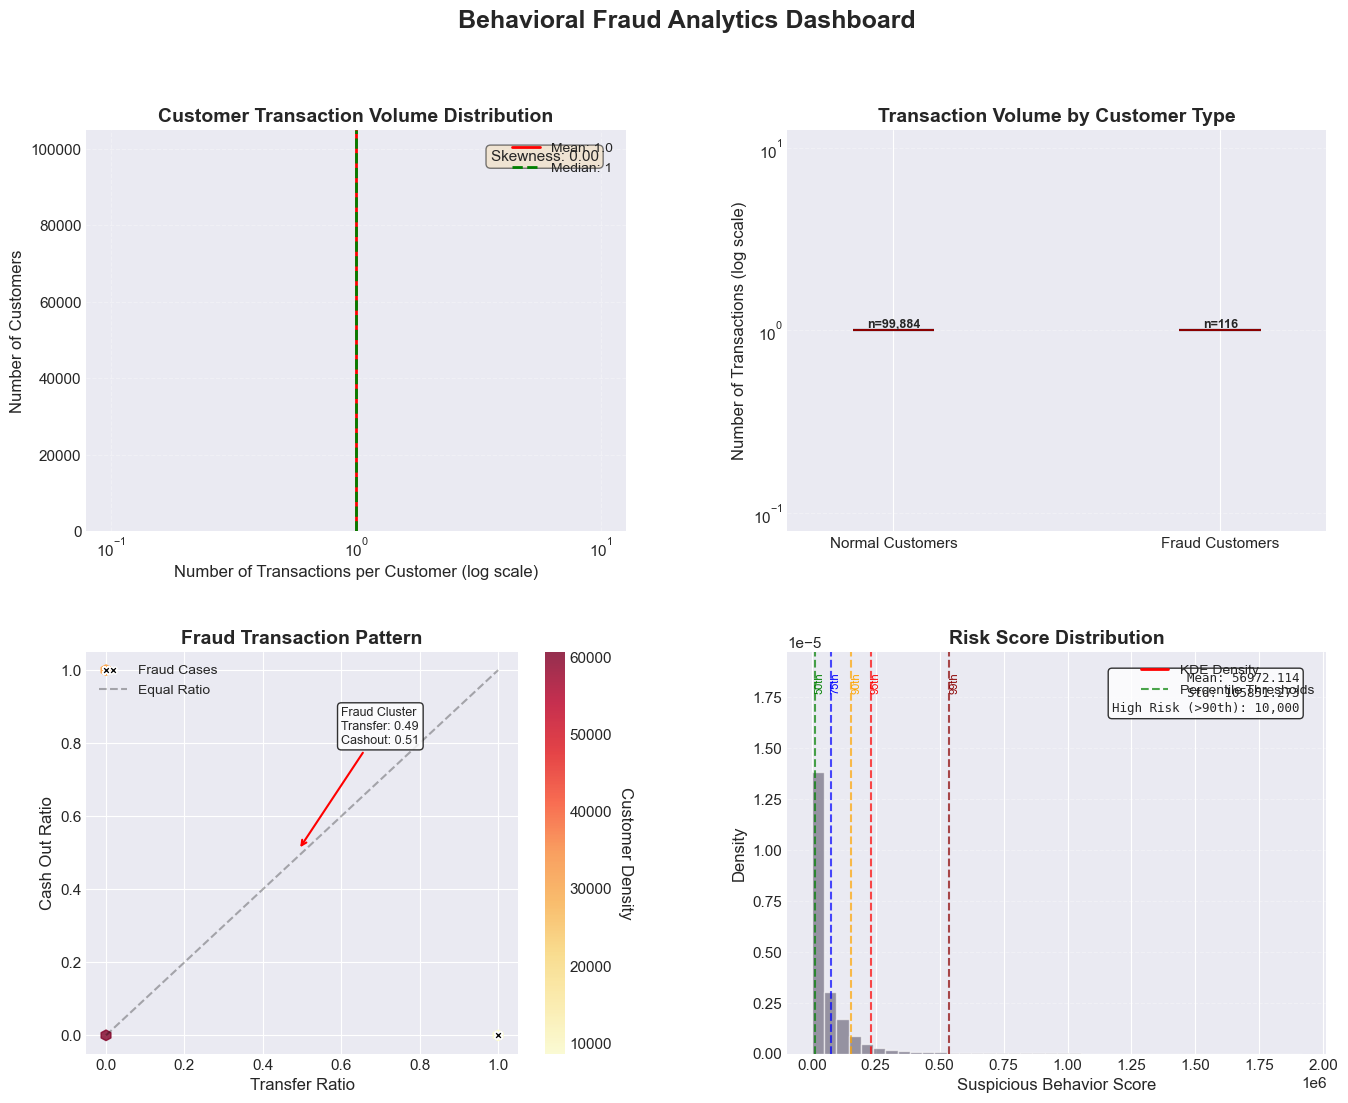

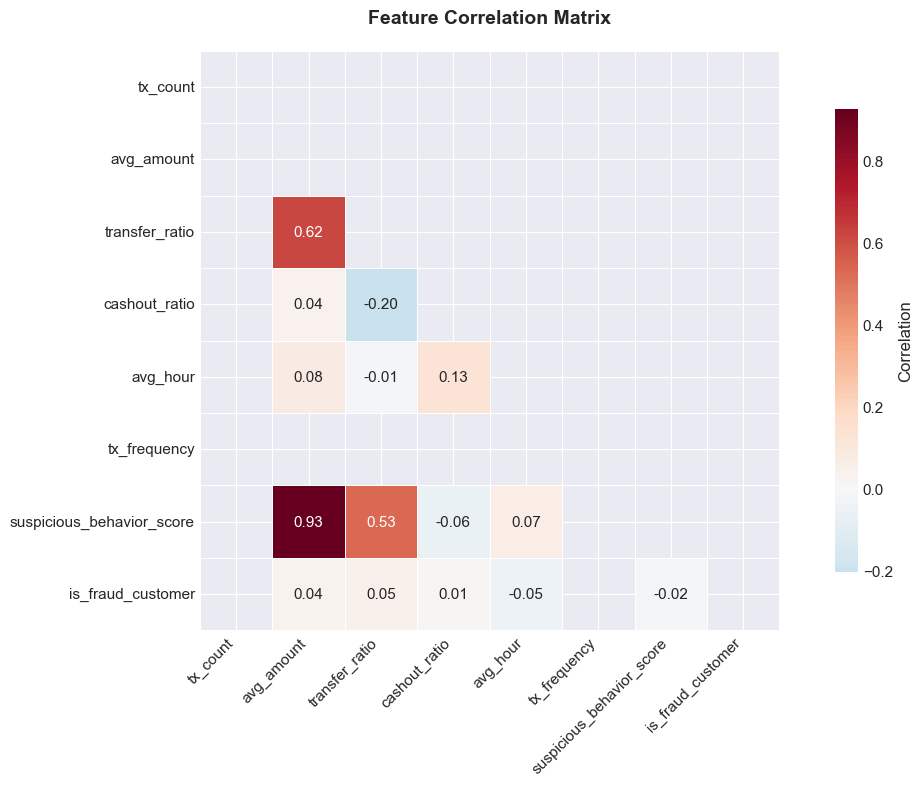


BEHAVIORAL ANALYTICS INSIGHTS

CUSTOMER SEGMENTATION
Total customers analyzed: 100,000
Fraudulent customers: 116 (0.12%)
High risk customers (>90th percentile): 10,000

TRANSACTION PATTERNS
Average transaction count per customer: 1.0
Fraud customers average transactions: 1.0
Normal customers average transactions: 1.0

KEY FINDINGS
Suspicious behavior score correlation with fraud: -0.02
Additional features or ensemble models may improve detection



In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
from scipy.stats import gaussian_kde

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.figsize'] = (12, 8)

fig = plt.figure(figsize=(16, 12))

gs = GridSpec(
    2,
    2,
    figure=fig,
    hspace=0.3,
    wspace=0.3
)

# Transaction Volume Distribution

ax1 = fig.add_subplot(gs[0, 0])

bins = np.logspace(
    np.log10(1),
    np.log10(customer_features['tx_count'].max()),
    30
)

ax1.hist(
    customer_features['tx_count'],
    bins=bins,
    alpha=0.7,
    color='#2E86AB',
    edgecolor='white',
    linewidth=0.5
)

ax1.set_xscale('log')

ax1.set_xlabel('Number of Transactions per Customer (log scale)')
ax1.set_ylabel('Number of Customers')

ax1.set_title(
    'Customer Transaction Volume Distribution',
    fontweight='bold'
)

ax1.grid(True, alpha=0.3, linestyle='--')

mean_tx = customer_features['tx_count'].mean()

median_tx = customer_features['tx_count'].median()

ax1.axvline(
    mean_tx,
    color='red',
    linestyle='-',
    linewidth=2,
    label=f'Mean: {mean_tx:.1f}'
)

ax1.axvline(
    median_tx,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Median: {median_tx:.0f}'
)

ax1.legend()

ax1.text(
    0.95,
    0.95,
    f'Skewness: {customer_features["tx_count"].skew():.2f}',
    transform=ax1.transAxes,
    ha='right',
    va='top',
    bbox=dict(
        boxstyle='round',
        facecolor='wheat',
        alpha=0.5
    )
)

# Fraud vs Normal Customers

ax2 = fig.add_subplot(gs[0, 1])

fraud_data = [
    customer_features[
        customer_features['is_fraud_customer'] == i
    ]['tx_count']
    for i in [0, 1]
]

positions = [1, 2]

labels = [
    'Normal Customers',
    'Fraud Customers'
]

parts = ax2.violinplot(
    fraud_data,
    positions=positions,
    showmeans=True,
    showmedians=True
)

colors = ['#A7C5BD', '#E88D67']

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)

parts['cmeans'].set_color('darkblue')
parts['cmedians'].set_color('darkred')

ax2.set_xticks(positions)

ax2.set_xticklabels(labels)

ax2.set_ylabel('Number of Transactions (log scale)')

ax2.set_yscale('log')

ax2.set_title(
    'Transaction Volume by Customer Type',
    fontweight='bold'
)

ax2.grid(
    True,
    alpha=0.3,
    linestyle='--',
    axis='y'
)

for i, data in enumerate(fraud_data):
    ax2.text(
        positions[i],
        max(data),
        f'n={len(data):,}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Transfer vs Cashout Pattern

ax3 = fig.add_subplot(gs[1, 0])

hb = ax3.hexbin(
    customer_features['transfer_ratio'],
    customer_features['cashout_ratio'],
    gridsize=40,
    cmap='YlOrRd',
    mincnt=1,
    alpha=0.8
)

fraud_points = customer_features[
    customer_features['is_fraud_customer'] == 1
]

ax3.scatter(
    fraud_points['transfer_ratio'],
    fraud_points['cashout_ratio'],
    color='black',
    s=30,
    marker='X',
    label='Fraud Cases',
    edgecolor='white',
    linewidth=1,
    zorder=3
)

ax3.set_xlabel('Transfer Ratio')

ax3.set_ylabel('Cash Out Ratio')

ax3.set_title(
    'Fraud Transaction Pattern',
    fontweight='bold'
)

ax3.set_xlim(-0.05, 1.05)

ax3.set_ylim(-0.05, 1.05)

cbar = plt.colorbar(hb, ax=ax3)

cbar.set_label(
    'Customer Density',
    rotation=270,
    labelpad=15
)

ax3.plot(
    [0, 1],
    [0, 1],
    'k--',
    alpha=0.3,
    label='Equal Ratio'
)

if len(fraud_points) > 0:

    avg_transfer = fraud_points['transfer_ratio'].mean()

    avg_cashout = fraud_points['cashout_ratio'].mean()

    ax3.annotate(
        f'Fraud Cluster\nTransfer: {avg_transfer:.2f}\nCashout: {avg_cashout:.2f}',
        xy=(avg_transfer, avg_cashout),
        xytext=(0.6, 0.8),
        arrowprops=dict(
            arrowstyle='->',
            color='red',
            lw=1.5
        ),
        fontsize=9,
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.8
        )
    )

ax3.legend(loc='upper left')

# Suspicious Behavior Score

ax4 = fig.add_subplot(gs[1, 1])

n, bins, patches = ax4.hist(
    customer_features['suspicious_behavior_score'],
    bins=40,
    density=True,
    alpha=0.6,
    color='#5D576B',
    edgecolor='white'
)

kde = gaussian_kde(
    customer_features['suspicious_behavior_score']
)

x_range = np.linspace(0, 1, 100)

ax4.plot(
    x_range,
    kde(x_range),
    'r-',
    linewidth=2,
    label='Density'
)

percentiles = [50, 75, 90, 95, 99]

colors = [
    'green',
    'blue',
    'orange',
    'red',
    'darkred'
]

for p, color in zip(percentiles, colors):

    value = customer_features[
        'suspicious_behavior_score'
    ].quantile(p / 100)

    ax4.axvline(
        value,
        color=color,
        linestyle='--',
        alpha=0.7,
        linewidth=1.5
    )

    ax4.text(
        value,
        ax4.get_ylim()[1] * 0.9,
        f'{p}th',
        rotation=90,
        fontsize=8,
        color=color
    )

ax4.set_xlabel('Suspicious Behavior Score')

ax4.set_ylabel('Density')

ax4.set_title(
    'Risk Score Distribution',
    fontweight='bold'
)

ax4.legend([
    'KDE Density',
    'Percentile Thresholds'
])

ax4.grid(
    True,
    alpha=0.3,
    linestyle='--',
    axis='y'
)

stats_text = (
    f"Mean: {customer_features['suspicious_behavior_score'].mean():.3f}\n"
    f"Std: {customer_features['suspicious_behavior_score'].std():.3f}\n"
    f"High Risk (>90th): "
    f"{(customer_features['suspicious_behavior_score'] > customer_features['suspicious_behavior_score'].quantile(0.9)).sum():,}"
)

ax4.text(
    0.95,
    0.95,
    stats_text,
    transform=ax4.transAxes,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.8
    ),
    fontsize=9,
    family='monospace'
)

plt.suptitle(
    'Behavioral Fraud Analytics Dashboard',
    fontsize=18,
    fontweight='bold',
    y=0.98
)

plt.tight_layout()

plt.show()

# Correlation Heatmap

plt.figure(figsize=(12, 8))

corr_cols = [
    'tx_count',
    'avg_amount',
    'transfer_ratio',
    'cashout_ratio',
    'avg_hour',
    'tx_frequency',
    'suspicious_behavior_score',
    'is_fraud_customer'
]

corr_matrix = customer_features[corr_cols].corr()

mask = np.triu(
    np.ones_like(corr_matrix, dtype=bool)
)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={
        "shrink": 0.8,
        "label": "Correlation"
    }
)

plt.title(
    'Feature Correlation Matrix',
    fontsize=14,
    fontweight='bold',
    pad=20
)

plt.xticks(rotation=45, ha='right')

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

# Insights

print("\n" + "=" * 60)

print("BEHAVIORAL ANALYTICS INSIGHTS")

print("=" * 60)

print(f"\nCUSTOMER SEGMENTATION")

print(
    f"Total customers analyzed: "
    f"{len(customer_features):,}"
)

print(
    f"Fraudulent customers: "
    f"{customer_features['is_fraud_customer'].sum():,} "
    f"({customer_features['is_fraud_customer'].mean():.2%})"
)

print(
    f"High risk customers (>90th percentile): "
    f"{(customer_features['suspicious_behavior_score'] > customer_features['suspicious_behavior_score'].quantile(0.9)).sum():,}"
)

print(f"\nTRANSACTION PATTERNS")

print(
    f"Average transaction count per customer: "
    f"{customer_features['tx_count'].mean():.1f}"
)

print(
    f"Fraud customers average transactions: "
    f"{customer_features[customer_features['is_fraud_customer']==1]['tx_count'].mean():.1f}"
)

print(
    f"Normal customers average transactions: "
    f"{customer_features[customer_features['is_fraud_customer']==0]['tx_count'].mean():.1f}"
)

print(f"\nKEY FINDINGS")

correlation = customer_features[
    'suspicious_behavior_score'
].corr(
    customer_features['is_fraud_customer']
)

if correlation > 0.3:

    print(
        f"Suspicious behavior score correlation with fraud: "
        f"{correlation:.2f}"
    )

    print(
        "Behavioral features are effectively identifying fraud patterns"
    )

else:

    print(
        f"Suspicious behavior score correlation with fraud: "
        f"{correlation:.2f}"
    )

    print(
        "Additional features or ensemble models may improve detection"
    )

print("\n" + "=" * 60)

In [39]:
pip install pyspark snowflake-connector-python snowflake-sqlalchemy


  Using cached snowflake_connector_python-4.5.0-cp312-cp312-win_amd64.whl.metadata (86 kB)
  Using cached snowflake_sqlalchemy-1.10.0-py3-none-any.whl.metadata (67 kB)
  Using cached boto3-1.43.15-py3-none-any.whl.metadata (6.6 kB)


ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\Payal\anaconda3\Lib\site-packages\pip\_internal\cli\base_command.py", line 180, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "C:\Users\Payal\anaconda3\Lib\site-packages\pip\_internal\cli\req_command.py", line 245, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Payal\anaconda3\Lib\site-packages\pip\_internal\commands\install.py", line 377, in run
    requirement_set = resolver.resolve(
                      ^^^^^^^^^^^^^^^^^
  File "C:\Users\Payal\anaconda3\Lib\site-packages\pip\_internal\resolution\resolvelib\resolver.py", line 95, in resolve
    result = self._result = resolver.resolve(
                            ^^^^^^^^^^^^^^^^^
  File "C:\Users\Payal\anaconda3\Lib\site-packages\pip\_vendor\resolvelib\resolvers.py", line 546, in resolve
    state = resolution.resolve(requirements, max_rounds=max_rounds)
            ^

In [42]:
import snowflake.connector
import pandas as pd

SNOWFLAKE_ACCOUNT = "mjxposb-ro16774"

SNOWFLAKE_USER = "PAYALJASUD"

SNOWFLAKE_PASSWORD = "Opayalm@249921"

SNOWFLAKE_WAREHOUSE = "COMPUTE_WH"

SNOWFLAKE_DATABASE = "FRAUD_ANALYTICS"

SNOWFLAKE_SCHEMA = "PAYSIM"

SNOWFLAKE_LOGIN_URL = (
    "https://mjxposb-ro16774.snowflakecomputing.com"
)

print("Testing Snowflake connection")

print(f"Username: {SNOWFLAKE_USER}")

print(f"Login URL: {SNOWFLAKE_LOGIN_URL}")

try:

    conn = snowflake.connector.connect(
        user=SNOWFLAKE_USER,
        password=SNOWFLAKE_PASSWORD,
        account=SNOWFLAKE_ACCOUNT,
        warehouse=SNOWFLAKE_WAREHOUSE
    )

    cur = conn.cursor()

    cur.execute("""
        SELECT
            CURRENT_VERSION(),
            CURRENT_WAREHOUSE()
    """)

    version, warehouse = cur.fetchone()

    print("\nConnected successfully")

    print(f"Snowflake version: {version}")

    print(f"Warehouse: {warehouse}")

    cur.close()

    conn.close()

except Exception as e:

    print(f"\nConnection failed: {e}")

    print("\nCheck:")
    print("Correct password")
    print("Email verification completed")
    print("Warehouse exists")

Testing Snowflake connection
Username: PAYALJASUD
Login URL: https://mjxposb-ro16774.snowflakecomputing.com

Connected successfully
Snowflake version: 10.19.100
Warehouse: COMPUTE_WH


In [43]:
import snowflake.connector
import pandas as pd

SNOWFLAKE_ACCOUNT = "mjxposb-ro16774"

SNOWFLAKE_USER = "PAYALJASUD"

SNOWFLAKE_PASSWORD = "Opayalm@249921"

SNOWFLAKE_WAREHOUSE = "COMPUTE_WH"

print(f"Your data: {len(df):,} transactions")

print(
    f"Customer profiles: "
    f"{len(customer_profiles):,} customers"
)

# Connect to Snowflake

conn = snowflake.connector.connect(
    user=SNOWFLAKE_USER,
    password=SNOWFLAKE_PASSWORD,
    account=SNOWFLAKE_ACCOUNT,
    warehouse=SNOWFLAKE_WAREHOUSE
)

cur = conn.cursor()

# Database and Schema

cur.execute("""
    CREATE DATABASE IF NOT EXISTS FRAUD_ANALYTICS
""")

cur.execute("""
    CREATE SCHEMA IF NOT EXISTS FRAUD_ANALYTICS.PAYSIM
""")

cur.execute("""
    USE DATABASE FRAUD_ANALYTICS
""")

cur.execute("""
    USE SCHEMA PAYSIM
""")

print("Database and schema ready")

# Create Tables

cur.execute("""
CREATE OR REPLACE TABLE transactions (
    step INT,
    type STRING,
    amount FLOAT,
    nameOrig STRING,
    oldbalanceOrg FLOAT,
    newbalanceOrig FLOAT,
    nameDest STRING,
    oldbalanceDest FLOAT,
    newbalanceDest FLOAT,
    isFraud INT,
    isFlaggedFraud INT,
    hour INT,
    is_TRANSFER INT,
    is_CASH_OUT INT,
    balance_error FLOAT
)
""")

cur.execute("""
CREATE OR REPLACE TABLE customer_profiles (
    customer_id STRING,
    tx_count INT,
    avg_amount FLOAT,
    total_amount FLOAT,
    std_amount FLOAT,
    is_fraud_customer INT,
    avg_hour FLOAT,
    transfer_ratio FLOAT,
    cashout_ratio FLOAT,
    avg_balance_error FLOAT,
    risk_score FLOAT,
    high_risk INT
)
""")

print("Tables created")

# Upload Transactions

print("\nUploading transactions")

transaction_data = df[[
    'step',
    'type',
    'amount',
    'nameOrig',
    'oldbalanceOrg',
    'newbalanceOrig',
    'nameDest',
    'oldbalanceDest',
    'newbalanceDest',
    'isFraud',
    'isFlaggedFraud',
    'hour',
    'is_TRANSFER',
    'is_CASH_OUT',
    'balance_error'
]].values.tolist()

batch_size = 5000

for i in range(0, len(transaction_data), batch_size):

    batch = transaction_data[i:i+batch_size]

    cur.executemany("""
        INSERT INTO transactions VALUES (
            %s, %s, %s, %s, %s,
            %s, %s, %s, %s, %s,
            %s, %s, %s, %s, %s
        )
    """, batch)

    print(
        f"Uploaded "
        f"{min(i+batch_size, len(transaction_data)):,}/"
        f"{len(transaction_data):,} rows"
    )

print("Transactions uploaded")

# Upload Customer Profiles

print("\nUploading customer profiles")

if 'risk_score' not in customer_profiles.columns:

    from sklearn.preprocessing import MinMaxScaler

    scaler = MinMaxScaler()

    customer_profiles['risk_score'] = scaler.fit_transform(
        customer_profiles[[
            'transfer_ratio',
            'cashout_ratio',
            'avg_balance_error'
        ]]
    ).mean(axis=1)

    customer_profiles['high_risk'] = (
        customer_profiles['risk_score'] >
        customer_profiles['risk_score'].quantile(0.9)
    ).astype(int)

profile_data = customer_profiles[[
    'customer_id',
    'tx_count',
    'avg_amount',
    'total_amount',
    'std_amount',
    'is_fraud_customer',
    'avg_hour',
    'transfer_ratio',
    'cashout_ratio',
    'avg_balance_error',
    'risk_score',
    'high_risk'
]].values.tolist()

for i in range(0, len(profile_data), batch_size):

    batch = profile_data[i:i+batch_size]

    cur.executemany("""
        INSERT INTO customer_profiles VALUES (
            %s, %s, %s, %s, %s, %s,
            %s, %s, %s, %s, %s, %s
        )
    """, batch)

    print(
        f"Uploaded "
        f"{min(i+batch_size, len(profile_data)):,}/"
        f"{len(profile_data):,} profiles"
    )

print("Customer profiles uploaded")

# Analytics Queries

print("\n" + "=" * 60)

print("SNOWFLAKE ANALYTICS")

print("=" * 60)

# Fraud by Transaction Type

cur.execute("""
    SELECT
        type,
        COUNT(*) as total,
        SUM(isFraud) as fraud_count,
        ROUND(
            SUM(isFraud) * 100.0 / COUNT(*),
            2
        ) as fraud_rate
    FROM transactions
    GROUP BY type
    ORDER BY fraud_rate DESC
""")

print("\nFraud Rate by Transaction Type")

for row in cur.fetchall():

    print(
        f"{row[0]:12s}: "
        f"{row[3]}% "
        f"({row[2]}/{row[1]} transactions)"
    )

# High Risk Customers

cur.execute("""
    SELECT
        customer_id,
        tx_count,
        ROUND(total_amount, 2) as amount,
        ROUND(risk_score, 3) as risk,
        CASE
            WHEN is_fraud_customer = 1
            THEN 'FRAUD'
            ELSE 'SUSPICIOUS'
        END as status
    FROM customer_profiles
    WHERE high_risk = 1
    ORDER BY risk_score DESC
    LIMIT 10
""")

print("\nTop 10 High Risk Customers")

for row in cur.fetchall():

    print(
        f"{row[0]:15s} | "
        f"Risk: {row[3]} | "
        f"Amount: ${row[2]:,.2f} | "
        f"{row[4]}"
    )

# Risk Distribution

cur.execute("""
    SELECT
        CASE
            WHEN risk_score < 0.25
                THEN 'Low Risk'
            WHEN risk_score < 0.5
                THEN 'Medium Risk'
            WHEN risk_score < 0.75
                THEN 'High Risk'
            ELSE 'Critical Risk'
        END as risk_level,

        COUNT(*) as customer_count,

        SUM(is_fraud_customer) as fraudsters

    FROM customer_profiles

    GROUP BY risk_level

    ORDER BY MIN(risk_score)
""")

print("\nRisk Distribution")

for row in cur.fetchall():

    detection_rate = (
        row[2] / row[1] * 100
    ) if row[1] > 0 else 0

    print(
        f"{row[0]:15s}: "
        f"{row[1]:4d} customers | "
        f"Fraudsters: {row[2]} | "
        f"Detection: {detection_rate:.1f}%"
    )

cur.close()

conn.close()

print("\nSnowflake upload and analytics complete")

print("Your data is now in the cloud")

Your data: 100,000 transactions
Customer profiles: 100,000 customers
Database and schema ready
Tables created

Uploading transactions
Uploaded 5,000/100,000 rows
Uploaded 10,000/100,000 rows
Uploaded 15,000/100,000 rows
Uploaded 20,000/100,000 rows
Uploaded 25,000/100,000 rows
Uploaded 30,000/100,000 rows
Uploaded 35,000/100,000 rows
Uploaded 40,000/100,000 rows
Uploaded 45,000/100,000 rows
Uploaded 50,000/100,000 rows
Uploaded 55,000/100,000 rows
Uploaded 60,000/100,000 rows
Uploaded 65,000/100,000 rows
Uploaded 70,000/100,000 rows
Uploaded 75,000/100,000 rows
Uploaded 80,000/100,000 rows
Uploaded 85,000/100,000 rows
Uploaded 90,000/100,000 rows
Uploaded 95,000/100,000 rows
Uploaded 100,000/100,000 rows
Transactions uploaded

Uploading customer profiles
Uploaded 5,000/100,000 profiles
Uploaded 10,000/100,000 profiles
Uploaded 15,000/100,000 profiles
Uploaded 20,000/100,000 profiles
Uploaded 25,000/100,000 profiles
Uploaded 30,000/100,000 profiles
Uploaded 35,000/100,000 profiles
Uploa

In [44]:
customer_profiles.to_csv("customer_risk_profiles.csv", index=False)
df.to_csv("transactions_engineered.csv", index=False)

print("Files saved! Nowww open Power BI Desktop")

Files saved! Nowww open Power BI Desktop
